# Árvores de regressão - exercícios 01

*Atenção! Devido descontinuação da base de imóveis boston os alunos devem utilizar a base de dados que se encontra em anexo.*

A base que utilizaremos contem os dados dos imóveis da california.
Considerem como variável Target (a ser prevista) a coluna median_house_value.
O dataset é muito semelhante ao de boston, contendo localização, quartos, banheiros e outras variáveis interessantes para construção do modelo.

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Carregando a base de dados da Califórnia
df = pd.read_csv('housing.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 1. Certifique-se de que esta base está no formato adequado para o scikitlearn.
ok, essa tarefa é tão fácil que você vai até desconfiar. Mas é preciso ter confiança sobre os dados que se usa ;)

In [6]:
# Verificando tipos e valores ausentes
print("=== Tipos de Dados ===")
print(df.dtypes)
print("\n=== Valores Ausentes ===")
print(df.isnull().sum())

# ocean_proximity é categórica — precisa ser codificada
# total_bedrooms possui valores ausentes — preencher com mediana
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# Codificando variável categórica com One-Hot Encoding
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=False)

print("\n=== Formato final ===")
print(f"Shape: {df.shape}")
print(df.dtypes)
print("\nValores ausentes após tratamento:", df.isnull().sum().sum())
df.head()


=== Tipos de Dados ===
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

=== Valores Ausentes ===
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

=== Formato final ===
Shape: (20640, 14)
longitude                     float64
latitude                      float64
housing_median_age            float64
total_rooms                   float64
total_bedrooms                float64
population                    float64
households                    float64
median_income                 float64
median_house_value

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


### 2.  Visualize a matriz de correlação, e veja se aparentemente você encontra alguma variável com potencial preditivo interessante.

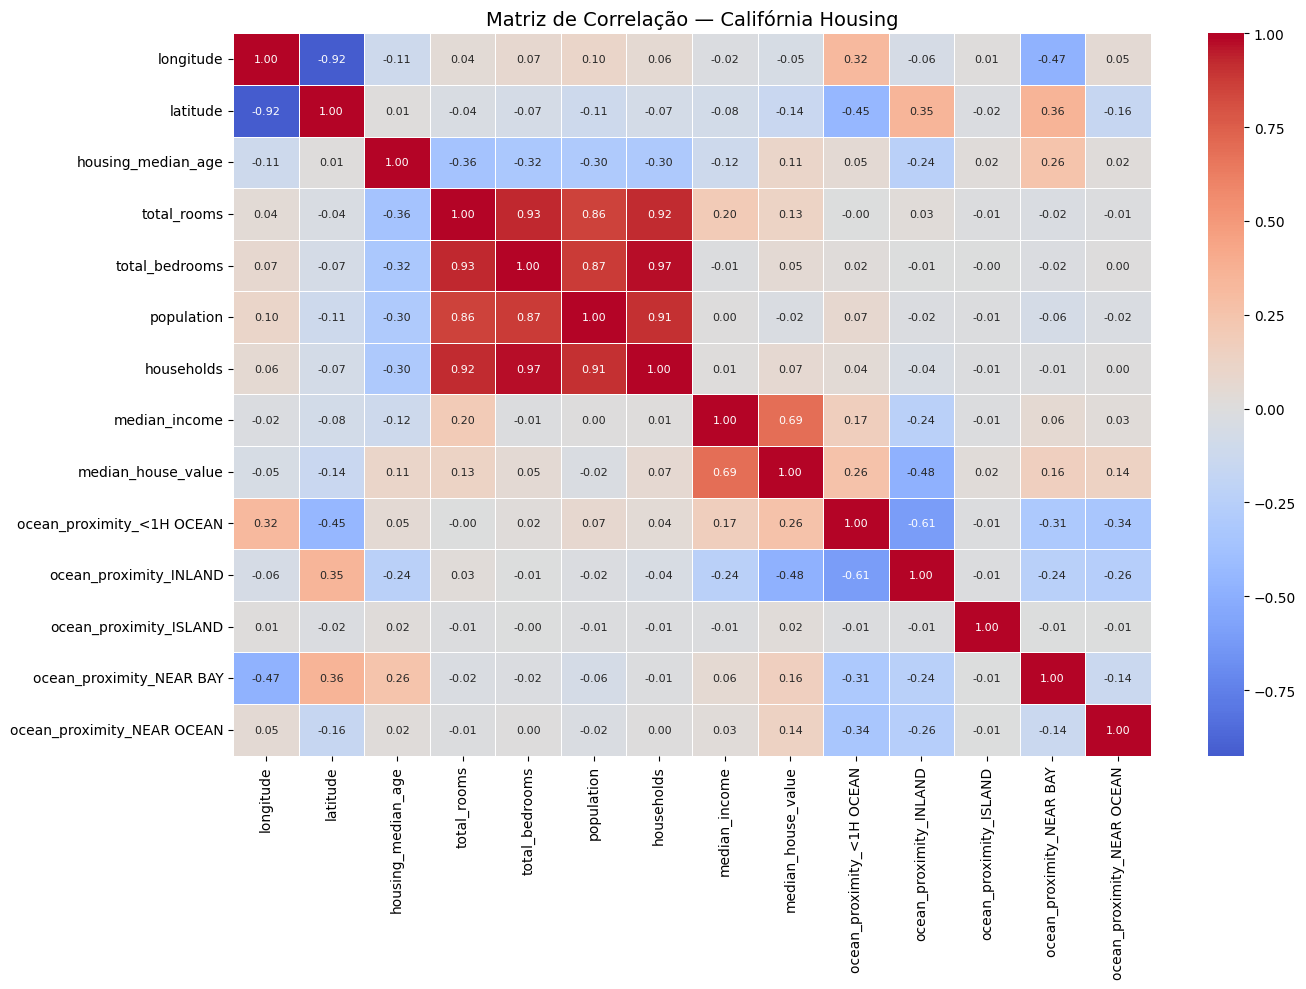

=== Correlação com median_house_value ===
median_income                 0.688075
ocean_proximity_<1H OCEAN     0.256617
ocean_proximity_NEAR BAY      0.160284
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
households                    0.065843
total_bedrooms                0.049457
ocean_proximity_ISLAND        0.023416
population                   -0.024650
longitude                    -0.045967
latitude                     -0.144160
ocean_proximity_INLAND       -0.484859
Name: median_house_value, dtype: float64


In [7]:
# Matriz de correlação das variáveis numéricas com o target
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de Correlação — Califórnia Housing', fontsize=14)
plt.tight_layout()
plt.show()

# Destacando correlações com o target
print("=== Correlação com median_house_value ===")
print(corr['median_house_value'].drop('median_house_value').sort_values(ascending=False))


### 3. Separe os dados em validação e teste

In [8]:
# Definindo features (X) e target (y)
target = 'median_house_value'
X = df.drop(columns=[target])
y = df[target]

# Split 80% treino / 20% teste, semente fixada para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")


Treino: 16512 amostras
Teste:  4128 amostras


### 4. Treine duas árvores, uma com profundidade máxima = 8, outra com profundidade máxima = 2.

In [9]:
# Árvore com profundidade máxima = 2
tree_d2 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_d2.fit(X_train, y_train)

# Árvore com profundidade máxima = 8
tree_d8 = DecisionTreeRegressor(max_depth=8, random_state=42)
tree_d8.fit(X_train, y_train)

print("Modelos treinados com sucesso.")
print(f"Árvore profundidade 2 — nº de folhas: {tree_d2.get_n_leaves()}")
print(f"Árvore profundidade 8 — nº de folhas: {tree_d8.get_n_leaves()}")


Modelos treinados com sucesso.
Árvore profundidade 2 — nº de folhas: 4
Árvore profundidade 8 — nº de folhas: 239


### 5. Calcule o MSE de cada uma das árvores do item anterior para a base de treinamento e para a base de testes.

        Modelo   MSE Treino    MSE Teste  RMSE Treino   RMSE Teste
Profundidade 2 6.710573e+09 6.893608e+09 81918.085075 83027.754093
Profundidade 8 3.253977e+09 3.904406e+09 57043.639838 62485.244552


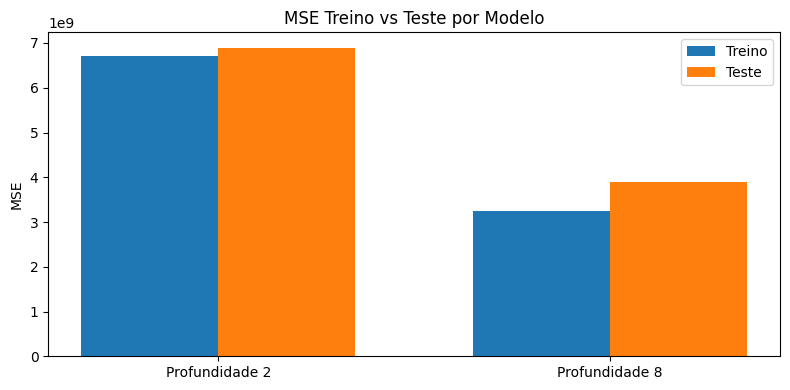

In [10]:
# MSE no treino
mse_d2_train = mean_squared_error(y_train, tree_d2.predict(X_train))
mse_d8_train = mean_squared_error(y_train, tree_d8.predict(X_train))

# MSE no teste
mse_d2_test = mean_squared_error(y_test, tree_d2.predict(X_test))
mse_d8_test = mean_squared_error(y_test, tree_d8.predict(X_test))

resultados = pd.DataFrame({
    'Modelo': ['Profundidade 2', 'Profundidade 8'],
    'MSE Treino': [mse_d2_train, mse_d8_train],
    'MSE Teste':  [mse_d2_test,  mse_d8_test],
    'RMSE Treino': [np.sqrt(mse_d2_train), np.sqrt(mse_d8_train)],
    'RMSE Teste':  [np.sqrt(mse_d2_test),  np.sqrt(mse_d8_test)],
})

print(resultados.to_string(index=False))

# Vizualização comparativa
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [mse_d2_train, mse_d8_train], width, label='Treino')
ax.bar(x + width/2, [mse_d2_test,  mse_d8_test],  width, label='Teste')
ax.set_xticks(x)
ax.set_xticklabels(['Profundidade 2', 'Profundidade 8'])
ax.set_ylabel('MSE')
ax.set_title('MSE Treino vs Teste por Modelo')
ax.legend()
plt.tight_layout()
plt.show()


### 6. Com base nos resultados do item anterior, qual árvore te parece mais adequada?

In [11]:
# Avaliação de overfitting: diferença entre MSE treino e teste
diff_d2 = mse_d2_test - mse_d2_train
diff_d8 = mse_d8_test - mse_d8_train

print(f"Profundidade 2 — Gap (Teste - Treino): {diff_d2:,.0f}")
print(f"Profundidade 8 — Gap (Teste - Treino): {diff_d8:,.0f}")


Profundidade 2 — Gap (Teste - Treino): 183,035,287
Profundidade 8 — Gap (Teste - Treino): 650,428,941


**Análise — Qual árvore é mais adequada?**

A árvore com **profundidade 8** apresenta MSE de treino consideravelmente menor, pois tem muito mais capacidade de memorizar os dados. No entanto, o critério de escolha correto é o desempenho na **base de teste**, que representa dados nunca vistos.

- **Profundidade 2**: modelo simples (underfitting) — erro de treino e teste próximos, mas ambos altos. O modelo não consegue capturar a complexidade dos dados.
- **Profundidade 8**: se o MSE de teste for aceitável e o gap treino/teste não for excessivo, é o modelo mais adequado — ele captura padrões relevantes sem memorizar o ruído.

> **Conclusão**: A árvore de **profundidade 8** é mais adequada, pois equilibra melhor a capacidade de aprendizado com a generalização. A grande diferença entre o MSE de treino e teste (gap) indica algum grau de overfitting, que será tratado com poda no assignment 02 via CCP-alpha.


### 7. Faça uma visualização gráfica dessa árvore. Vamos discutir importância de variável mais adiante, mas veja a sua árvore, e pense um pouco: qual variável te parece mais "importante" na árvore?

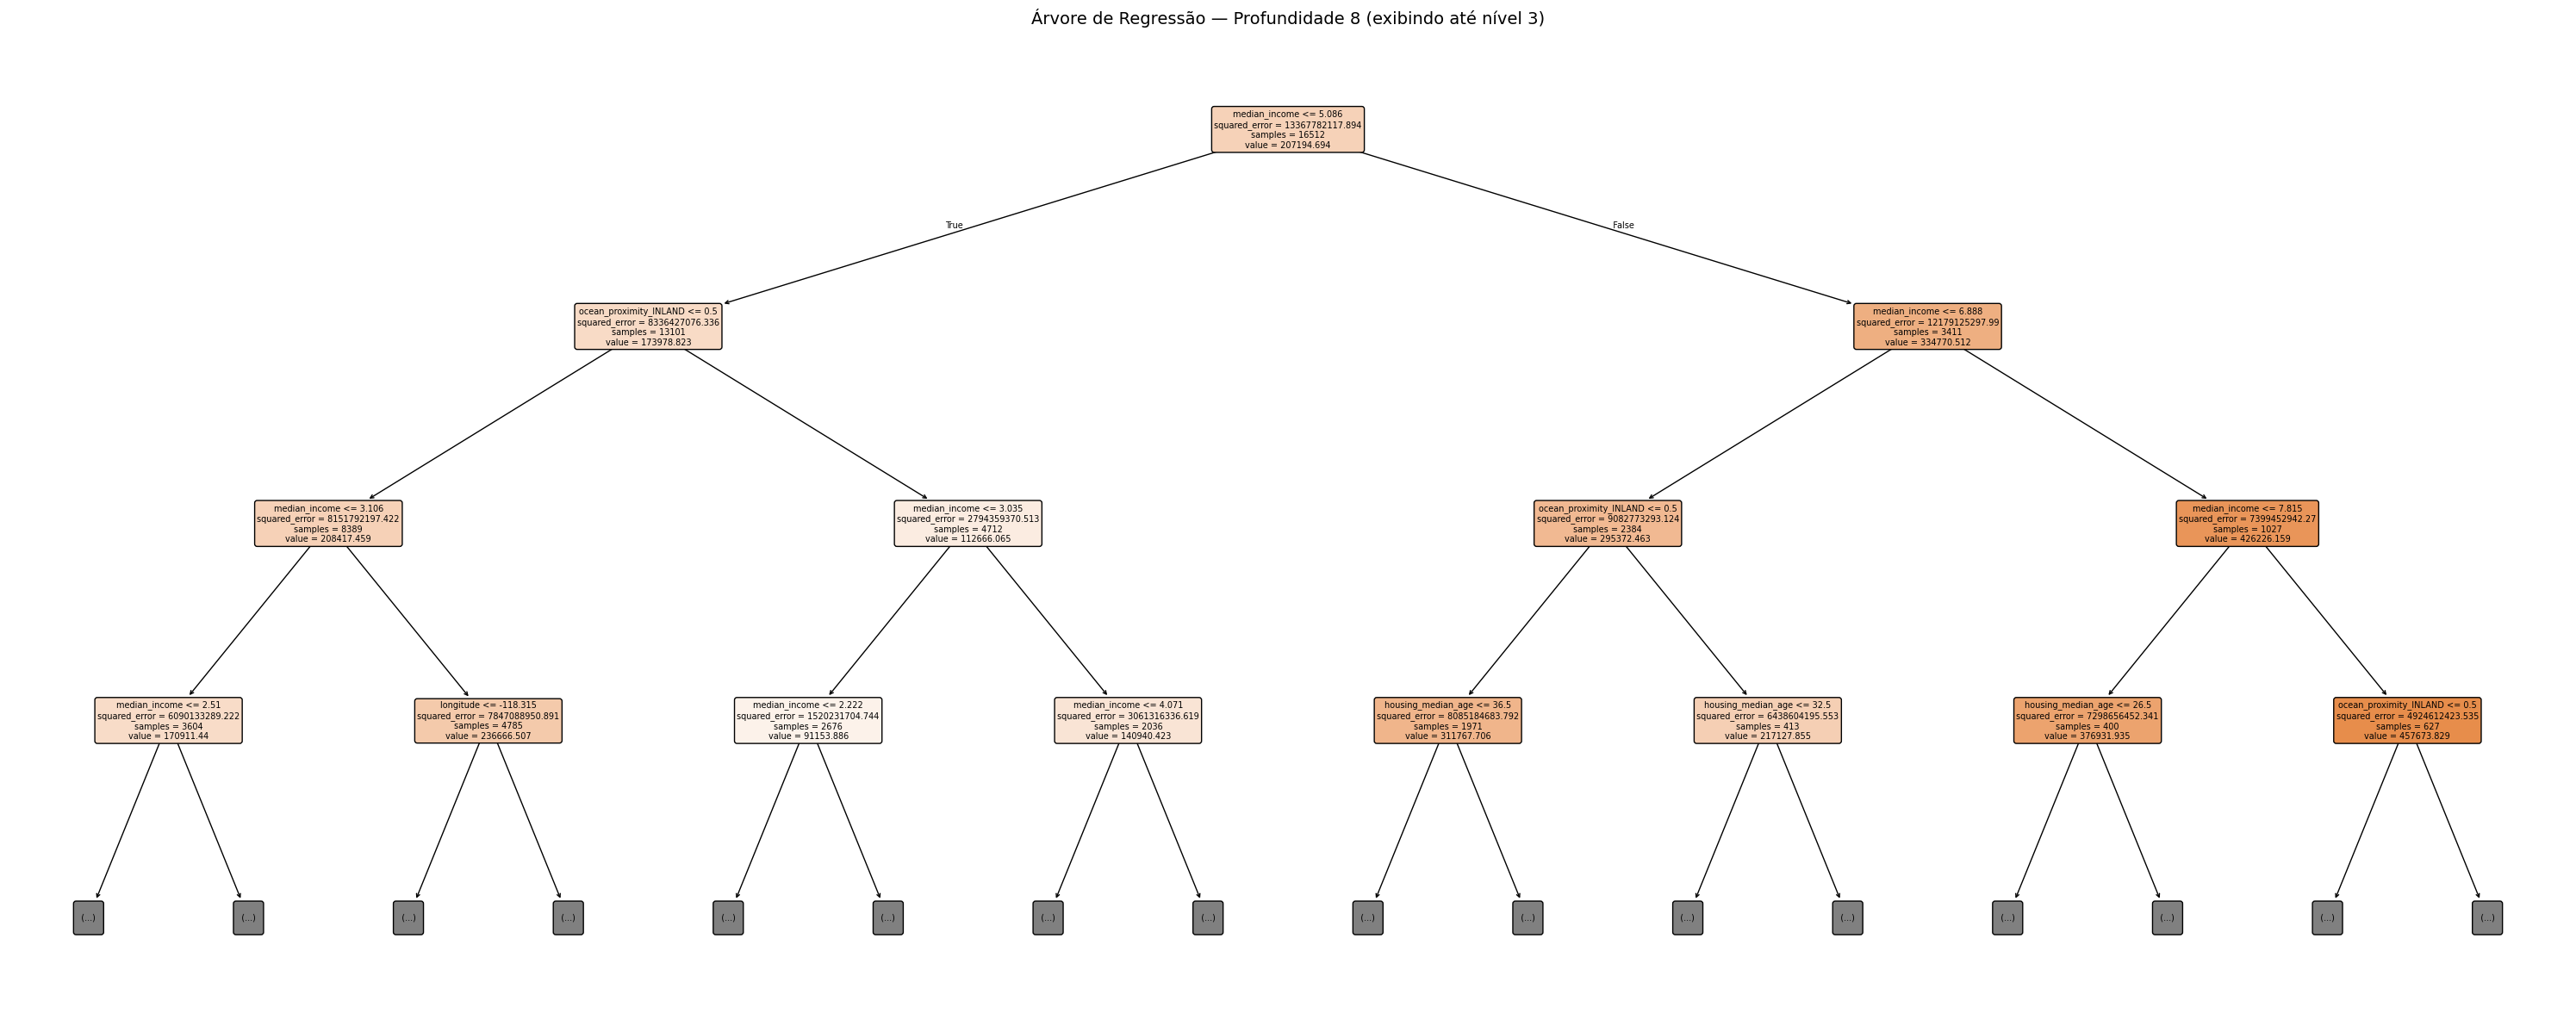

C:\Users\rodrigo.a.nascimento\AppData\Local\Temp\ipykernel_3088\3637311024.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='viridis')


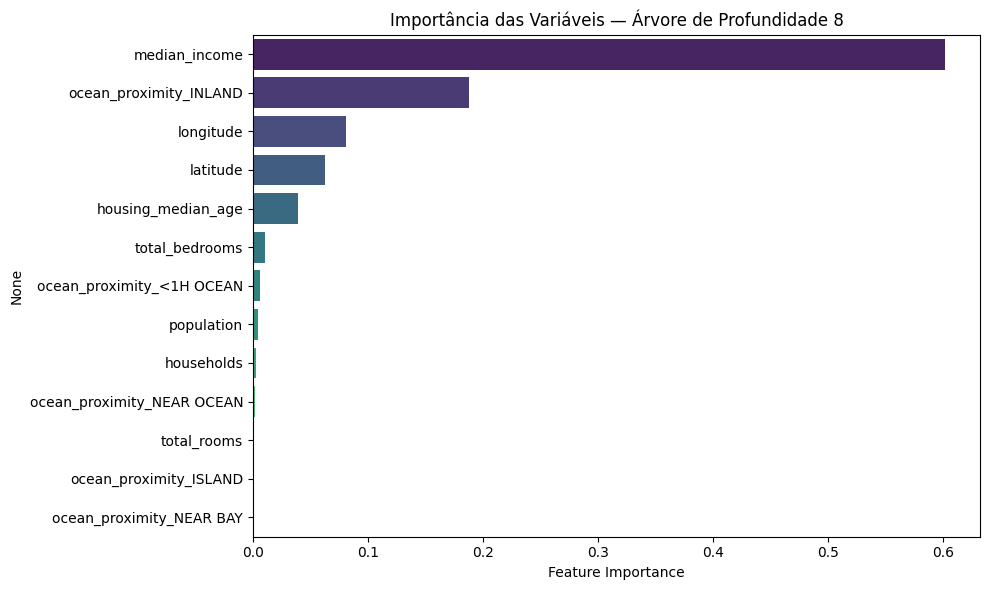

=== Top 5 Variáveis Mais Importantes ===
median_income             0.602364
ocean_proximity_INLAND    0.187986
longitude                 0.080863
latitude                  0.062370
housing_median_age        0.039021
dtype: float64


In [12]:
# Visualização gráfica da árvore de profundidade 8
plt.figure(figsize=(30, 12))
tree.plot_tree(
    tree_d8,
    feature_names=X.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=7,
    max_depth=3         # exibe apenas os 3 primeiros níveis para legibilidade
)
plt.title('Árvore de Regressão — Profundidade 8 (exibindo até nível 3)', fontsize=14)
plt.tight_layout()
plt.show()

# Importância das variáveis
feat_importance = pd.Series(tree_d8.feature_importances_, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='viridis')
plt.title('Importância das Variáveis — Árvore de Profundidade 8')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

print("=== Top 5 Variáveis Mais Importantes ===")
print(feat_importance.head())


**Análise — Qual variável parece mais importante na árvore?**

Observando tanto a visualização gráfica (os primeiros nós de decisão) quanto o gráfico de feature importance, a variável **`median_income`** (renda mediana dos domicílios no quarteirão) destaca-se como a mais importante para prever o valor do imóvel.

Isso faz sentido intuitivo: **regiões com maior renda tendem a ter imóveis mais caros**. Localização (`latitude`, `longitude`) e `housing_median_age` também contribuem significativamente, refletindo que imóveis mais novos e bem localizados (próximos à costa) têm maior valor.

> **Conclusão**: `median_income` é a variável preditiva dominante no modelo, aparecendo nos primeiros nós da árvore — que são os cortes mais relevantes para redução do MSE global.
